# Notebook 06 - OLAP, datamart et KPI

## Objectif

Maintenant que le DWH existe, on construit la couche de restitution.

Un datamart sert à exposer un sous-ensemble orienté métier, plus simple et plus rapide d'accès pour l'analyse. 

## Ce qu'on va produire

- `dm_notice_kpi`
- `kpi_publications_by_day`
- `kpi_avg_delay_by_market_type`
- `kpi_top_buyers`
- `kpi_top_primary_cpv`
- `kpi_reject_rate_by_batch`


In [1]:
# Nous importons pandas.
import pandas as pd

# Nous importons matplotlib pour quelques graphiques simples.
import matplotlib.pyplot as plt

# Nous importons la bibliothèque pathlib pour manipuler les chemins de fichiers proprement.
from pathlib import Path

In [2]:
# Nous définissons un chemin de départ qui correspond au dossier courant du notebook.
current_dir = Path.cwd().resolve()

# Si le notebook est exécuté depuis le dossier du projet, ce test sera vrai.
if (current_dir / "data").exists():
    # Dans ce cas, le dossier courant est déjà la racine du projet.
    project_root = current_dir
else:
    # Sinon, on suppose que le notebook est exécuté depuis le dossier notebooks.
    project_root = current_dir.parent

# Nous définissons ici le dossier qui contient les lots bruts.
data_dir = project_root / "data" / "raw_batches"

# Nous définissons ici le dossier de sortie.
output_dir = project_root / "outputs"

# Nous affichons la racine retenue pour éviter toute ambiguïté.
print("project_root =", project_root)

# Nous affichons la liste des fichiers bruts disponibles.
print("raw files =", sorted(p.name for p in data_dir.glob("*.json")))

project_root = D:\Ens-EPSI\boamp_etl_dwh_tiny_explained_project
raw files = ['B20150308_01_initial.json', 'B20150309_01_incremental.json', 'B20150309_01_rerun.json']


## Étape 1 - Charger le DWH et les tables ops

In [3]:
# Nous lisons les dimensions.
dim_date = pd.read_csv(output_dir / "warehouse" / "dim_date.csv")
dim_buyer = pd.read_csv(output_dir / "warehouse" / "dim_buyer.csv")
dim_market_type = pd.read_csv(output_dir / "warehouse" / "dim_market_type.csv")
dim_cpv = pd.read_csv(output_dir / "warehouse" / "dim_cpv.csv")

# Nous lisons les facts.
fact_notice_publication = pd.read_csv(output_dir / "warehouse" / "fact_notice_publication.csv")
fact_notice_cpv = pd.read_csv(output_dir / "warehouse" / "fact_notice_cpv.csv")

# Nous lisons les runs de jobs.
ops_job_run = pd.read_csv(output_dir / "ops" / "ops_job_run.csv")

# Nous convertissons les dates utiles.
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])
ops_job_run["start_ts"] = pd.to_datetime(ops_job_run["start_ts"], utc=True)
ops_job_run["end_ts"] = pd.to_datetime(ops_job_run["end_ts"], utc=True)

# Nous affichons les principales tables chargées.
display(dim_date)
display(fact_notice_publication)
display(fact_notice_cpv)
display(ops_job_run.head())

,date_key,full_date,year,month,day,month_label
0,20150303,2015-03-03,2015,3,3,2015-03
1,20150304,2015-03-04,2015,3,4,2015-03
2,20150305,2015-03-05,2015,3,5,2015-03
3,20150306,2015-03-06,2015,3,6,2015-03
4,20150307,2015-03-07,2015,3,7,2015-03
5,20150308,2015-03-08,2015,3,8,2015-03


,fact_notice_key,notice_business_id,date_key,buyer_key,market_type_key,notice_count,response_delay_days,has_deadline_flag,batch_id,url_avis,objet_court
0,1,15-31501,20150303,3,3,1,48,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-31501,concession d'aménagement pour la réalisation d...
1,2,15-40000,20150304,6,3,1,14,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40000,maintenance de bâtiments scolaires et travaux ...
2,3,15-40001,20150305,5,1,1,20,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40001,fourniture de matériel informatique pour les s...
3,4,15-40002,20150306,2,2,1,14,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40002,prestations de nettoyage des locaux administra...
4,5,15-40003,20150307,4,3,1,23,True,B20150309_01_incremental,https://www.boamp.fr/pages/avis/?q=idweb:15-40003,travaux d'aménagement de voirie et signalisation
5,6,15-40004,20150308,1,2,1,14,True,B20150309_01_incremental,https://www.boamp.fr/pages/avis/?q=idweb:15-40004,services d'assistance juridique en urbanisme


,fact_notice_key,notice_business_id,date_key,cpv_key,is_primary_flag
0,1,15-31501,20150303,3,True
1,1,15-31501,20150303,9,False
2,1,15-31501,20150303,8,False
3,2,15-40000,20150304,5,True
4,2,15-40000,20150304,7,False
5,3,15-40001,20150305,1,True
6,3,15-40001,20150305,6,False
7,4,15-40002,20150306,11,True
8,5,15-40003,20150307,4,True
9,5,15-40003,20150307,2,False


,run_id,job_name,batch_id,start_ts,end_ts,duration_seconds,status,retry_count,rows_read,rows_rejected
0,RUN_001,collect_boamp_batch,B20150308_01_initial,2015-03-08 05:30:00+00:00,2015-03-08 05:32:00+00:00,120,SUCCESS,0,4,0
1,RUN_002,stage_boamp_notice,B20150308_01_initial,2015-03-08 05:30:00+00:00,2015-03-08 05:32:00+00:00,120,SUCCESS,0,4,0
2,RUN_003,transform_notice_kpi,B20150308_01_initial,2015-03-08 05:30:00+00:00,2015-03-08 05:31:00+00:00,60,SUCCESS,0,4,0
3,RUN_004,load_notice_dwh,B20150308_01_initial,2015-03-08 05:30:00+00:00,2015-03-08 05:31:00+00:00,60,SUCCESS,0,4,0
4,RUN_005,refresh_kpi_tables,B20150308_01_initial,2015-03-08 05:30:00+00:00,2015-03-08 05:31:00+00:00,60,SUCCESS,0,4,0


## Étape 2 - Construire un datamart simple

Le datamart `dm_notice_kpi` est une table de restitution lisible par un analyste.

On y rejoint la fact principale avec les dimensions nécessaires.

In [4]:
# Nous joignons la fact principale avec la dimension date.
dm_notice_kpi = fact_notice_publication.merge(dim_date, on="date_key", how="left")

# Nous joignons ensuite la dimension acheteur.
dm_notice_kpi = dm_notice_kpi.merge(dim_buyer, on="buyer_key", how="left")

# Nous joignons ensuite la dimension type de marché.
dm_notice_kpi = dm_notice_kpi.merge(dim_market_type, on="market_type_key", how="left")

# Nous affichons le datamart obtenu.
dm_notice_kpi

,fact_notice_key,notice_business_id,date_key,buyer_key,market_type_key,notice_count,response_delay_days,has_deadline_flag,batch_id,url_avis,objet_court,full_date,year,month,day,month_label,buyer_name,market_type_code
0,1,15-31501,20150303,3,3,1,48,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-31501,concession d'aménagement pour la réalisation d...,2015-03-03,2015,3,3,2015-03,Cté Cnes Moyenne Vilaine et Semnon,TRAVAUX
1,2,15-40000,20150304,6,3,1,14,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40000,maintenance de bâtiments scolaires et travaux ...,2015-03-04,2015,3,4,2015-03,Ville de Rennes,TRAVAUX
2,3,15-40001,20150305,5,1,1,20,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40001,fourniture de matériel informatique pour les s...,2015-03-05,2015,3,5,2015-03,Ville de Nantes,FOURNITURES
3,4,15-40002,20150306,2,2,1,14,True,B20150308_01_initial,https://www.boamp.fr/pages/avis/?q=idweb:15-40002,prestations de nettoyage des locaux administra...,2015-03-06,2015,3,6,2015-03,Conseil départemental de Loire-Atlantique,SERVICES
4,5,15-40003,20150307,4,3,1,23,True,B20150309_01_incremental,https://www.boamp.fr/pages/avis/?q=idweb:15-40003,travaux d'aménagement de voirie et signalisation,2015-03-07,2015,3,7,2015-03,Métropole de Lyon,TRAVAUX
5,6,15-40004,20150308,1,2,1,14,True,B20150309_01_incremental,https://www.boamp.fr/pages/avis/?q=idweb:15-40004,services d'assistance juridique en urbanisme,2015-03-08,2015,3,8,2015-03,Communauté urbaine de Bordeaux,SERVICES


## Étape 3 - Calculer les KPI

Nous gardons les KPI définis dès le cadrage initial.

C'est important : le pipeline n'invente pas les KPI à la fin.  
Il a été construit **pour eux**.

In [5]:
# KPI 1 : nombre d'avis publiés par jour.
kpi_publications_by_day = (
    dm_notice_kpi
    .groupby("full_date", as_index=False)["notice_count"]
    .sum()
    .rename(columns={"notice_count": "published_notice_count"})
)

# KPI 2 : délai moyen de réponse par type de marché.
kpi_avg_delay_by_market_type = (
    dm_notice_kpi
    .groupby("market_type_code", as_index=False)["response_delay_days"]
    .mean()
    .rename(columns={"response_delay_days": "avg_response_delay_days"})
)

# KPI 3 : top acheteurs par volume.
kpi_top_buyers = (
    dm_notice_kpi
    .groupby("buyer_name", as_index=False)["notice_count"]
    .sum()
    .rename(columns={"notice_count": "notice_volume"})
    .sort_values("notice_volume", ascending=False)
)

# Pour le KPI CPV, nous joignons la fact CPV avec la dimension CPV.
fact_cpv_enriched = fact_notice_cpv.merge(dim_cpv, on="cpv_key", how="left")

# KPI 4 : top CPV principaux.
kpi_top_primary_cpv = (
    fact_cpv_enriched[fact_cpv_enriched["is_primary_flag"]]
    .groupby("cpv_code", as_index=False)["notice_business_id"]
    .nunique()
    .rename(columns={"notice_business_id": "notice_volume"})
    .sort_values("notice_volume", ascending=False)
)

# KPI 5 : taux de rejet par batch via la couche ops.
kpi_reject_rate_by_batch = (
    ops_job_run[ops_job_run["job_name"] == "stage_boamp_notice"]
    .assign(reject_rate=lambda d: d["rows_rejected"] / d["rows_read"])
    [["batch_id", "rows_read", "rows_rejected", "reject_rate"]]
)

# Nous affichons les KPI.
display(kpi_publications_by_day)
display(kpi_avg_delay_by_market_type)
display(kpi_top_buyers)
display(kpi_top_primary_cpv)
display(kpi_reject_rate_by_batch)

,full_date,published_notice_count
0,2015-03-03,1
1,2015-03-04,1
2,2015-03-05,1
3,2015-03-06,1
4,2015-03-07,1
5,2015-03-08,1


,market_type_code,avg_response_delay_days
0,FOURNITURES,20.000000
1,SERVICES,14.000000
2,TRAVAUX,28.333333


,buyer_name,notice_volume
0,Communauté urbaine de Bordeaux,1
1,Conseil départemental de Loire-Atlantique,1
2,Cté Cnes Moyenne Vilaine et Semnon,1
3,Métropole de Lyon,1
4,Ville de Nantes,1
5,Ville de Rennes,1


,cpv_code,notice_volume
0,30200000,1
1,45111291,1
2,45233140,1
3,45453100,1
4,79111000,1
5,90910000,1


,batch_id,rows_read,rows_rejected,reject_rate
1,B20150308_01_initial,4,0,0.000000
6,B20150309_01_incremental,3,1,0.333333
11,B20150309_01_rerun,3,0,0.000000


## Étape 4 - Sauvegarder le datamart et les KPI

In [6]:
# Nous définissons le dossier des datamarts.
datamart_dir = output_dir / "datamarts"

# Nous créons le dossier si besoin.
datamart_dir.mkdir(parents=True, exist_ok=True)

# Nous écrivons le datamart principal.
dm_notice_kpi.to_csv(datamart_dir / "dm_notice_kpi.csv", index=False)

# Nous écrivons tous les KPI.
kpi_publications_by_day.to_csv(datamart_dir / "kpi_publications_by_day.csv", index=False)
kpi_avg_delay_by_market_type.to_csv(datamart_dir / "kpi_avg_delay_by_market_type.csv", index=False)
kpi_top_buyers.to_csv(datamart_dir / "kpi_top_buyers.csv", index=False)
kpi_top_primary_cpv.to_csv(datamart_dir / "kpi_top_primary_cpv.csv", index=False)
kpi_reject_rate_by_batch.to_csv(datamart_dir / "kpi_reject_rate_by_batch.csv", index=False)

# Nous affichons les fichiers créés.
sorted(p.name for p in datamart_dir.glob("*.csv"))

['dm_notice_kpi.csv',
 'kpi_avg_delay_by_market_type.csv',
 'kpi_publications_by_day.csv',
 'kpi_reject_rate_by_batch.csv',
 'kpi_top_buyers.csv',
 'kpi_top_primary_cpv.csv']

## Étape 5 - Représenter visuellement deux KPI

L'objectif n'est pas de faire un dashboard complet, mais de montrer que la structure construite permet déjà la restitution.


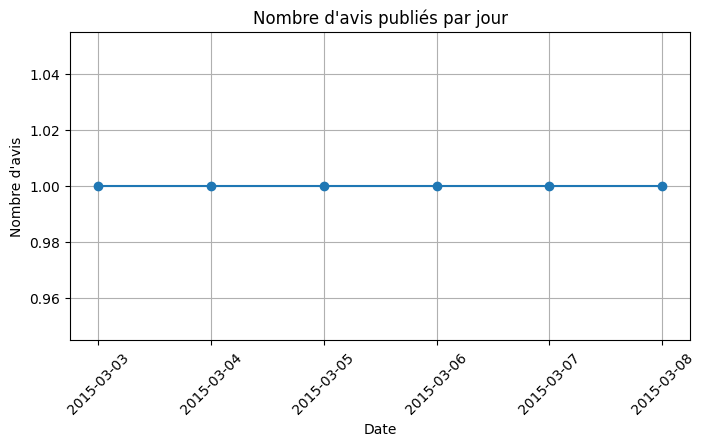

In [7]:
# Nous créons un premier graphique pour les publications par jour.
plt.figure(figsize=(8, 4))

# Nous traçons la courbe de volume.
plt.plot(kpi_publications_by_day["full_date"], kpi_publications_by_day["published_notice_count"], marker="o")

# Nous donnons un titre.
plt.title("Nombre d'avis publiés par jour")

# Nous nommons les axes.
plt.xlabel("Date")
plt.ylabel("Nombre d'avis")

# Nous inclinons légèrement les dates pour la lisibilité.
plt.xticks(rotation=45)

# Nous affichons une grille légère.
plt.grid(True)

# Nous affichons le graphique.
plt.show()

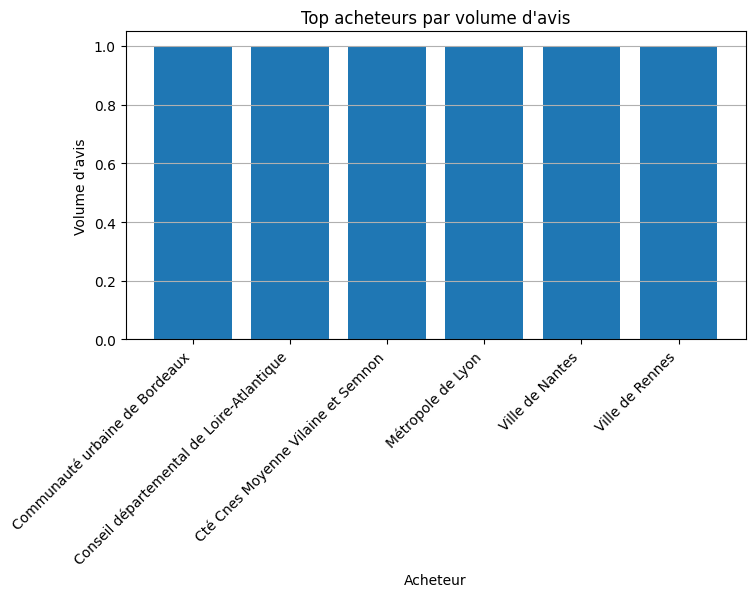

In [8]:
# Nous créons un second graphique pour le volume par acheteur.
plt.figure(figsize=(8, 4))

# Nous traçons des barres.
plt.bar(kpi_top_buyers["buyer_name"], kpi_top_buyers["notice_volume"])

# Nous donnons un titre.
plt.title("Top acheteurs par volume d'avis")

# Nous nommons les axes.
plt.xlabel("Acheteur")
plt.ylabel("Volume d'avis")

# Nous inclinons les libellés d'axe pour la lisibilité.
plt.xticks(rotation=45, ha="right")

# Nous affichons une grille légère sur l'axe vertical.
plt.grid(True, axis="y")

# Nous affichons le graphique.
plt.show()

## Conclusion 

Avec très peu de tables, on a montré l'essentiel :

- collecte,
- batch control,
- staging brut / standardisé / rejet,
- transformation métier,
- DWH orienté KPI,
- jobs,
- monitoring,
- datamart,
- KPI.
